Сомтрим, как влияет атмосферная рефракция на применимость моделей астрометрической редукции. При каком размере рабочего поля можно полагаться на линейную модель редукции?

In [1]:
from math import *
import numpy as np
from datetime import datetime
from astropy.time import Time

def tangFromRADE(ra, dec, RA, DEC):
    ksi = cos(dec)*sin(ra-RA)/(sin(dec)*sin(DEC)+cos(dec)*cos(DEC)*cos(ra-RA))
    eta = (sin(dec)*cos(DEC)-cos(dec)*sin(DEC)*cos(ra-RA))/(sin(dec)*sin(DEC)+cos(dec)*cos(DEC)*cos(ra-RA))
    return ksi,eta

def RADecFromTang(ksi, eta, RA, Dec):
    x,y,z = np.dot(np.array([[-sin(RA),-cos(RA) * sin(Dec),cos(RA) * cos(Dec)],
                             [cos(RA),-sin(RA) * sin(Dec),sin(RA) * cos(Dec)],
                             [0,cos(Dec),sin(Dec)]]),
                   np.array([ksi,eta,1]))/sqrt(1+ksi*ksi+eta*eta)
    ra = atan2(y,x)
    dec = atan2(z,sqrt(x*x+y*y))
    if(ra<0):
        ra+=2*pi
    return ra,dec

def getSiderial(JD, lon):
    MJD = JD - 2400000.5
    H = (MJD - trunc(MJD))*24.0
    D = JD - 2451545.0
    D0 = trunc(MJD) - 51544.5
    T = D/36525
    LST = 6.697374558 + 0.06570982441908*D0 + 1.00273790935*H + 0.000026*T*T+degrees(lon)/15
    return pi*(LST - 24.0*trunc(LST/24.0))/12.0

def RADECtoAzEl(ra,dec,s,lat):
    Phi = lat-pi/2.0
    e = np.array([cos(s-ra)*cos(dec),sin(s-ra)*cos(dec),sin(dec)])
    h = np.array([cos(Phi)*e[0]+sin(Phi)*e[2],e[1],-sin(Phi)*e[0]+cos(Phi)*e[2]])
    cosd = sqrt(h[0] * h[0] + h[1] * h[1])
    return atan2(h[1] / cosd, h[0] / cosd), atan2(h[2], cosd)

In [2]:
# ваша функция учета рефракции
def refraction(ra,dec, s, lat, JD, t, P, wl):
    ra_ref,dec_ref = ra+radians(0.1/3600),dec+radians(0.1/3600)

    return ra_ref,dec_ref


In [3]:
lon = radians(30.327498)
lat = radians(59.771831)
P = 750
t = 7
wl = 0.55
ra,dec = radians(60.0),radians(-20.0)

JD = float(Time(datetime.utcnow()).copy(format='jd').value)
print(JD)

2461171.1096863453


/var/folders/hy/8vvv51316x9388z2zyw61jgm0000gn/T/ipykernel_23711/2432350929.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  JD = float(Time(datetime.utcnow()).copy(format='jd').value)


-2.6592165863755146
uw errors = 0.0002, 0.0003,N = 100, Nu = 100, Q = 3


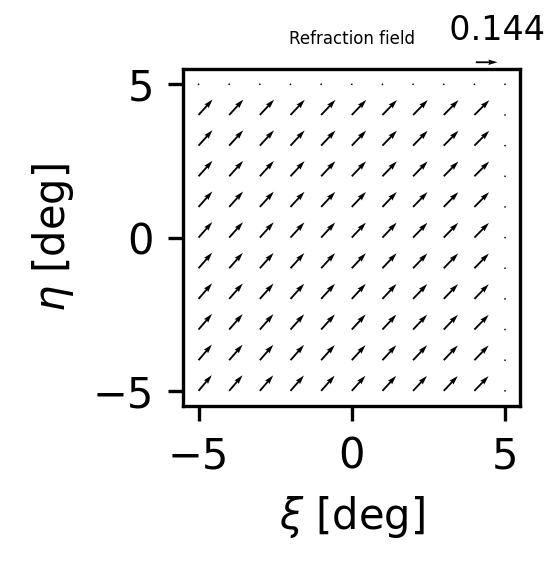

In [4]:
hfov = 5.0
Np = 11
ksi = np.linspace(-hfov,hfov,Np)
eta = np.linspace(-hfov,hfov,Np)
ksi,eta = np.meshgrid(ksi,eta)

delta_x,delta_y = np.zeros((Np,Np)),np.zeros((Np,Np))
step = 2*hfov/(Np-1)
s = getSiderial(JD,lon)
Az,El = RADECtoAzEl(ra,dec,s,lat)

print(degrees(El))
for i in range(Np-1):
    for j in range(Np-1):
        ra1,dec1 = RADecFromTang(radians(ksi[i,j]),radians(eta[i,j]),ra,dec)
        ra_ref, dec_ref = refraction(ra1,dec1,s,lat,JD,t,P,wl)
        tx, ty = tangFromRADE(ra_ref, dec_ref, ra, dec)
        x, y = degrees(tx), degrees(ty)

        delta_x[i,j] = 3600*(x - ksi[i,j])
        delta_y[i, j] = 3600*(y - eta[i,j])

import matplotlib.pyplot as plt
scv = '%7.3f'%(sqrt(delta_x.max()**2+delta_y.max()**2))
fig, ax = plt.subplots(figsize=(2.5,2), dpi=300, tight_layout=True)
ax.set_aspect('equal')
q = plt.quiver(ksi,eta,delta_x,delta_y)
ax.quiverkey(q, X=0.9, Y=1.02, U=sqrt(delta_x.max()**2+delta_y.max()**2),
                 label=scv, labelpos='N', angle = 00, labelsep = 0.05,fontproperties={'size': 8})
# plt.xlim(0,w)
# plt.ylim(0,h)
plt.xlabel('$\\xi$ [deg]')
plt.ylabel('$\\eta$ [deg]')
plt.title('Refraction field', fontsize=4)
# plt.savefig('refraction_field.png')
# plt.show()


def calibration(x,y,ksi,eta,n,Nmin,rmax):
    Q = int((n+1)*(n+2)/2)
    C = np.ones((np.size(x), Q))
    q = 0
    for i in range(n + 1):
        for j in range(n + 1):
            if (i + j <= n):
                C[:, q] = (x ** i) * (y ** j)
                q += 1
    We = np.diag(np.ones(np.size(x)))
    flag = 0
    it = 0
    while (flag == 0):
        Zx = np.dot(np.linalg.inv(np.dot(np.dot(np.transpose(C), We), C)), np.dot(np.dot(np.transpose(C), We), ksi))
        Zy = np.dot(np.linalg.inv(np.dot(np.dot(np.transpose(C), We), C)), np.dot(np.dot(np.transpose(C), We), eta))
        rx = np.dot(We, ksi - np.dot(C, Zx))
        ry = np.dot(We, eta - np.dot(C, Zy))
        r = np.sqrt(rx ** 2 + ry ** 2)
        kmax = np.argmax(r)
        flag = 1
        if (np.size(ksi) - it - Q <= Nmin):
            break
        if (r[kmax] > rmax):
            We[kmax, kmax] = 0
            flag = 0
            it += 1
    uwex = np.dot(np.dot(np.transpose(rx), We), rx) / (np.size(x) - it - Q)
    uwey = np.dot(np.dot(np.transpose(ry), We), ry) / (np.size(y) - it - Q)
    return Zx,Zy,sqrt(uwex),sqrt(uwey),np.size(x)-it

N = (Np-1)*(Np-1)
ksi = np.reshape(ksi[0:Np-1,0:Np-1],N)
eta = np.reshape(eta[0:Np-1,0:Np-1],N)
delta_x = np.reshape(delta_x[0:Np-1,0:Np-1],N)
delta_y = np.reshape(delta_y[0:Np-1,0:Np-1],N)


n = 1
Q = int((n + 1) * (n + 2) / 2)
Zx, Zy, uwex, uwey, nrs = calibration(ksi, eta, delta_x, delta_y, n, Q + 3, 20)
print('uw errors = %6.4f, %6.4f,N = %d, Nu = %d, Q = %d' % ( uwex, uwey, np.size(delta_x), nrs, Q))
